 Suno AI Reddit Dataset Exploratory Analysis

 This notebook explores the merged JSONL dataset:

 - Counts total posts and downloaded songs

 - Counts posts with predicted genres

 - Visualizes the most common genres

 - Analyzes top-3 genres distribution

 - Explores genre score distributions

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Configure pandas display
pd.set_option("display.max_columns", None)


 ## 1. Load Data

 Read the JSONL file into a DataFrame.

In [10]:
data_path = "suno_ai_posts_merged.jsonl"
df = pd.read_json(data_path, lines=True)
df.head()


,all_awardings,allow_live_comments,approved_at_utc,approved_by,archived,author,author_flair_background_color,author_flair_css_class,author_flair_richtext,author_flair_template_id,author_flair_text,author_flair_text_color,author_flair_type,author_fullname,author_is_blocked,author_patreon_flair,author_premium,awarders,banned_at_utc,banned_by,can_gild,can_mod_post,category,clicked,content_categories,contest_mode,created,created_utc,discussion_type,distinguished,domain,downs,edited,gilded,gildings,hidden,hide_score,id,is_created_from_ads_ui,is_crosspostable,is_meta,is_original_content,is_reddit_media_domain,is_robot_indexable,is_self,is_video,likes,link_flair_background_color,link_flair_css_class,link_flair_richtext,link_flair_text,link_flair_text_color,link_flair_type,locked,media,media_embed,media_only,mod_note,mod_reason_by,mod_reason_title,mod_reports,name,no_follow,num_comments,num_crossposts,num_reports,over_18,parent_whitelist_status,permalink,pinned,pwls,quarantine,removal_reason,removed_by,removed_by_category,report_reasons,retrieved_on,saved,score,secure_media,secure_media_embed,selftext,send_replies,spoiler,stickied,subreddit,subreddit_id,subreddit_name_prefixed,subreddit_subscribers,subreddit_type,suggested_sort,thumbnail,thumbnail_height,thumbnail_width,title,top_awarded_type,total_awards_received,treatment_tags,ups,upvote_ratio,url,user_reports,view_count,visited,whitelist_status,wls,post_hint,preview,url_overridden_by_dest,_meta,crosspost_parent,crosspost_parent_list,previous_selftext,media_metadata,author_cakeday,poll_data,gallery_data,is_gallery,link_flair_template_id,download_status,download_path,download_reason,predicted_genres,top_3_genres,genre_scores
0,[],True,NaN,NaN,False,HOLUPREDICTIONS,None,None,[],None,None,None,text,t2_gi7a36v6,False,0.0,0.0,[],NaN,NaN,False,False,NaN,False,NaN,False,1689958757,1689958757,CHAT,None,self.SunoAI,0,0,0,{},False,True,155tnr3,False,False,False,False,False,True,True,False,NaN,,None,[],None,dark,text,False,None,{},False,NaN,NaN,NaN,[],t3_155tnr3,True,0,0,0.0,False,None,/r/SunoAI/comments/155tnr3/rsunoai_lounge/,False,NaN,False,NaN,NaN,None,[],1689958770,False,1,None,{},A place for members of r/SunoAI to chat with e...,True,False,True,SunoAI,t5_8w65pa,r/SunoAI,1,public,new,self,NaN,NaN,r/SunoAI Lounge,NaN,0,[],1,1.00,https://www.reddit.com/r/SunoAI/comments/155tn...,[],NaN,False,None,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,None,None,[],[],[]
1,[],False,NaN,NaN,False,RiskyTrizkit,None,None,[],None,None,None,text,t2_7s78f,False,0.0,0.0,[],NaN,NaN,False,False,NaN,False,NaN,False,1691073331,1691073331,None,None,v.redd.it,0,0,0,{},False,True,15h5yqx,False,False,False,False,True,True,False,True,NaN,,None,[],None,dark,text,False,"{'reddit_video': {'bitrate_kbps': 0, 'dash_url...",{},False,NaN,NaN,NaN,[],t3_15h5yqx,True,0,0,0.0,False,None,/r/SunoAI/comments/15h5yqx/suno_handles_phonet...,False,NaN,False,NaN,NaN,None,[],1691073348,False,1,"{'reddit_video': {'bitrate_kbps': 0, 'dash_url...",{},,True,False,False,SunoAI,t5_8w65pa,r/SunoAI,2,public,None,https://a.thumbs.redditmedia.com/1BvlmPFKweA37...,70.0,140.0,Suno handles phonetics and onomatopoeia really...,NaN,0,[],1,1.00,https://v.redd.it/rjew9iy0pwfb1,[],NaN,False,None,NaN,hosted:video,"{'enabled': False, 'images': [{'id': 'ZHTFryEN...",https://v.redd.it/rjew9iy0pwfb1,None,None,None,None,None,NaN,None,None,NaN,None,None,None,None,[],[],[]
2,[],False,NaN,NaN,False,DtNothing,None,None,[],None,None,None,text,t2_59182sc5,False,0.0,0.0,[],NaN,NaN,False,False,NaN,False,NaN,False,1696536750,1696536750,None,None,youtube.com,0,0,0,{},False,True,170s0lx,False,True,False,False,False,True,False,False,NaN,,None,[],None,dark,text,False,"{'oembed': {'author_name': 'Jeff Boerst', 'aut...","{'content': '<iframe width=""267"" height=""200"" ...",False,NaN,NaN,NaN,[],t3_170s0lx,True,1,0,0.0,False,None,/r/SunoAI/comments/170s0lx/methane_mary/,False,NaN,False,NaN,NaN,None,[],1696536762,False,1,"{'oembed': {'author_name': 

 ## 2. Basic Counts

 - Total posts

 - How many have a downloaded audio file (`download_path`)\#

 - How many have predicted genres

In [11]:
# Total posts
total_posts = len(df)
# Downloaded songs
downloaded = df["download_path"].notnull().sum()
# Have at least one predicted genre
has_genre = (
    df["predicted_genres"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
)

print(f"Total posts: {total_posts}")
print(f"Downloaded songs: {downloaded}")
print(f"Posts with predicted genres: {has_genre}")


Total posts: 33626
Downloaded songs: 12783
Posts with predicted genres: 5244


 ## 3. Most Common Predicted Genres

 Flatten all predicted genres and count occurrences.

In [12]:
all_genres_series = df.loc[
    df["predicted_genres"].map(bool), "predicted_genres"
].explode()
genre_counts = all_genres_series.value_counts()
print(genre_counts.head(10))


predicted_genres
electronic    1382
rock          1273
pop           1045
classical      477
metal          340
hiphop         330
soundtrack     172
ambient         87
rap             82
reggae          76
Name: count, dtype: int64


 ## 4. Plot Top Predicted Genres

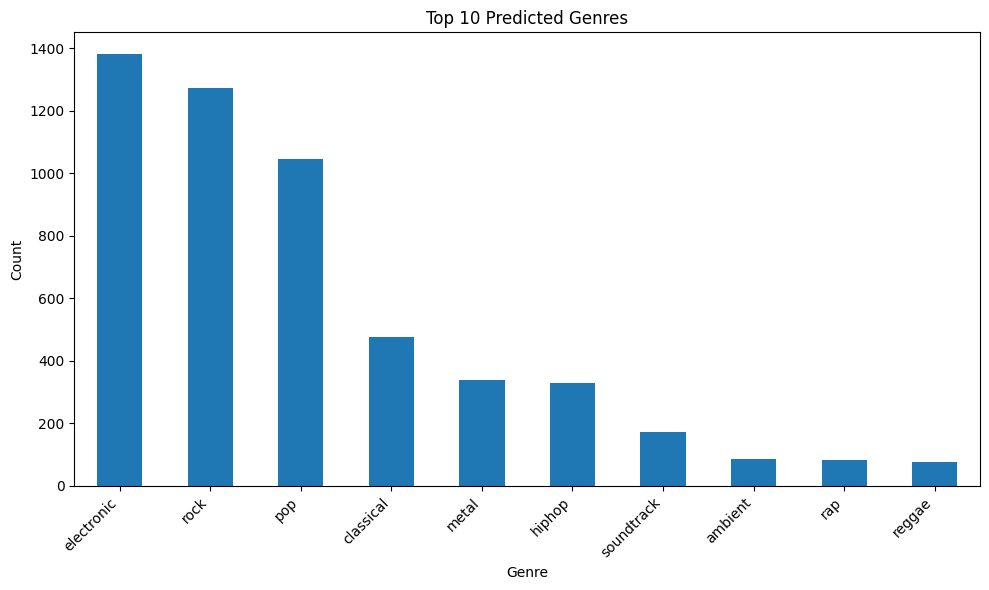

In [13]:
plt.figure(figsize=(10, 6))
genre_counts.head(10).plot(kind="bar")
plt.title("Top 10 Predicted Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 5. Distribution of Number of Predicted Genres per Post

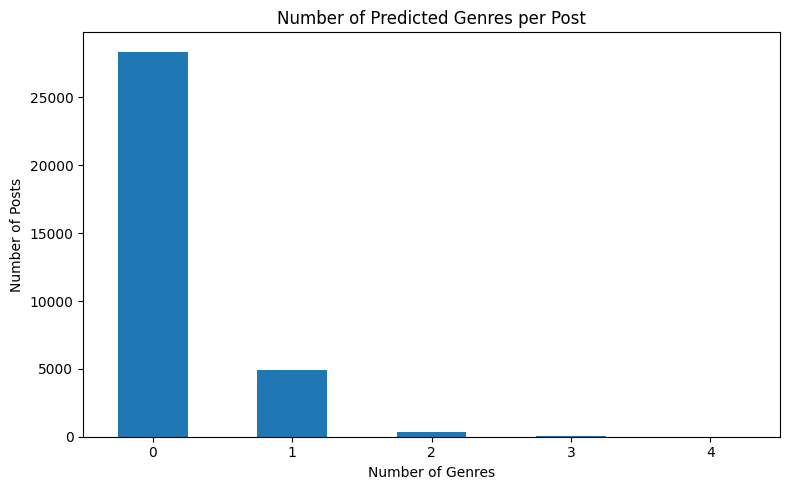

In [14]:
df["num_predicted"] = df["predicted_genres"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
counts_per_song = df["num_predicted"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
counts_per_song.plot(kind="bar")
plt.title("Number of Predicted Genres per Post")
plt.xlabel("Number of Genres")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


 ## 6. Most Common Top-3 Genres

 Flatten the `top_3_genres` lists and count.

In [15]:
top3_series = df.loc[df["top_3_genres"].map(bool), "top_3_genres"].explode()
top3_counts = top3_series.value_counts()
print(top3_counts.head(10))


top_3_genres
electronic     6330
pop            6008
rock           4094
soundtrack     2974
ambient        2144
classical      1740
alternative    1634
hiphop         1469
metal          1120
popfolk        1017
Name: count, dtype: int64


 ## 7. Plot Top-3 Genre Counts

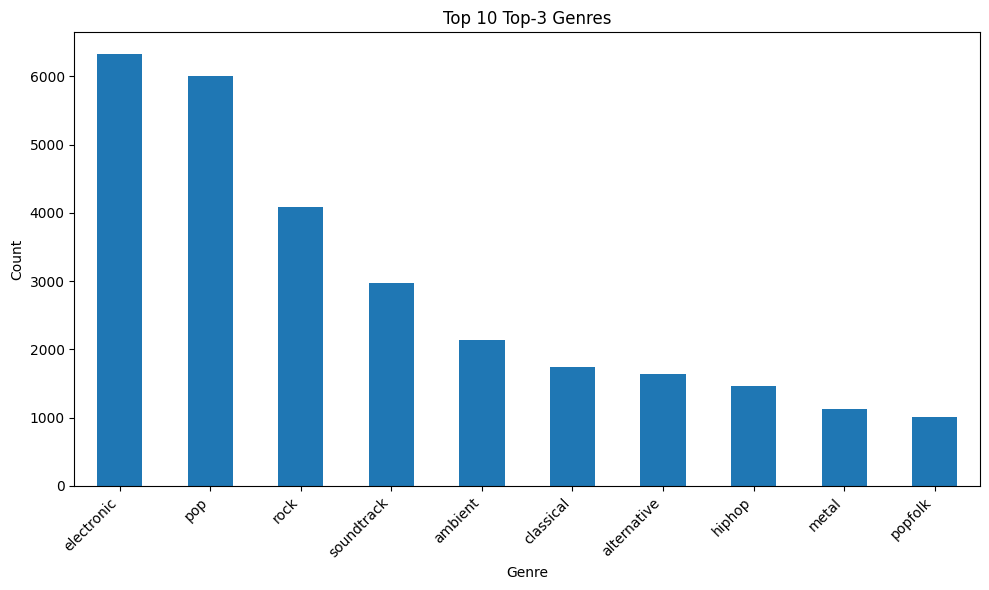

In [16]:
plt.figure(figsize=(10, 6))
top3_counts.head(10).plot(kind="bar", color=None)
plt.title("Top 10 Top-3 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 8. Genre Score Analysis

 Build a long-form DataFrame of each top-3 genre with its score and position.

In [18]:
records = []
for _, row in df.iterrows():
    genres = row.get("top_3_genres") or []
    scores = row.get("genre_scores") or []
    for pos, (g, s) in enumerate(zip(genres, scores), start=1):
        records.append({"position": pos, "genre": g, "score": s})
scores_long = pd.DataFrame(records)

# Descriptive stats
desc = scores_long["score"].describe()
print(desc)


count    37725.000000
mean         0.314817
std          0.163505
min          0.021434
25%          0.188548
50%          0.271266
75%          0.409008
max          0.997083
Name: score, dtype: float64


 ### 8.1 Score Distribution by Position

<Figure size 800x600 with 0 Axes>

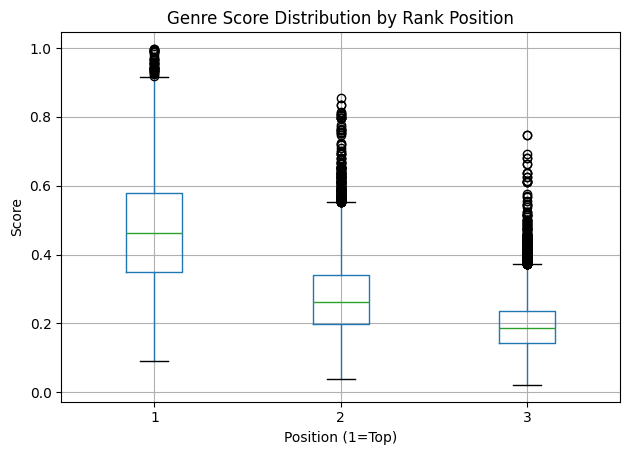

In [19]:
plt.figure(figsize=(8, 6))
scores_long.boxplot(column="score", by="position")
plt.title("Genre Score Distribution by Rank Position")
plt.suptitle("")  # remove automatic title
plt.xlabel("Position (1=Top)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


 ### 8.2 Average Score of Top-1 Genres

genre
rap           0.748268
punkrock      0.646710
downtempo     0.620089
trance        0.591156
indie         0.577907
orchestral    0.550956
metal         0.549689
dubstep       0.538692
rock          0.534961
hiphop        0.524132
Name: score, dtype: float64


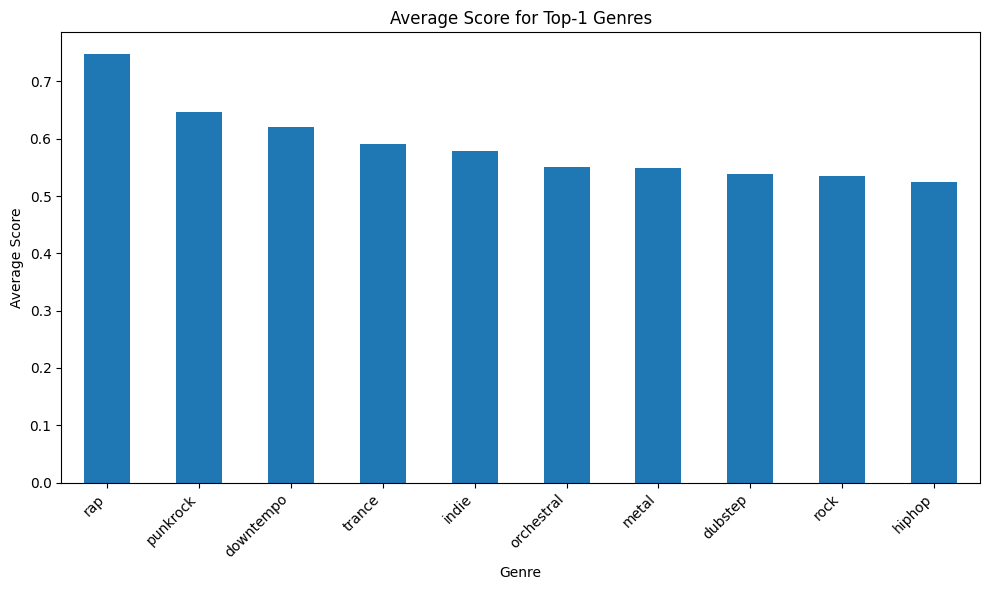

In [20]:
avg_top1 = (
    scores_long[scores_long["position"] == 1]
    .groupby("genre")["score"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_top1.head(10))

plt.figure(figsize=(10, 6))
avg_top1.head(10).plot(kind="bar")
plt.title("Average Score for Top-1 Genres")
plt.xlabel("Genre")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 9. Save Summaries

 - Genre counts and top-3 counts to CSV

 - Scores long-form to CSV

In [ ]:
# summary = pd.DataFrame({"genre": genre_counts.index, "count": genre_counts.values})
# summary.to_csv("predicted_genre_counts.csv", index=False)

# top3_summary = pd.DataFrame({"genre": top3_counts.index, "count": top3_counts.values})
# top3_summary.to_csv("top3_genre_counts.csv", index=False)

# scores_long.to_csv("genre_scores_long.csv", index=False)
# print("Saved summaries to CSV files.")


Saved summaries to CSV files.
